In [ ]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from musiq.analysis import final_density_matrix, state_fidelity
from musiq.pulse.sequence import PulseCompiler
from musiq.workflow import create_model, load_config


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)


In [2]:
model = create_model(
    circuits=MODEL_DIR / "circuit_bell_n4.yaml",
    devices=MODEL_DIR / "device.yaml",
    pulses=MODEL_DIR / "pulse.yaml",
    solvers=MODEL_DIR / "solver.yaml",
    analysers=MODEL_DIR / "analyser.yaml",
)
model.run_all()

analysis = model.analyses["case_0"]
print("solver keys =", sorted(model.solvers.keys()))
print("runs keys =", sorted(model.runs.keys()))
print("analysis keys =", sorted(model.analyses.keys()))
print("metric keys =", sorted(analysis.output.metrics.keys()))


solver keys = ['solver_0']
runs keys = ['run_0', 'run_1']
analysis keys = ['case_0', 'case_1']
metric keys = ['coherence_01', 'leakage', 'population']


In [3]:
solver_run = model.runs["run_0"]
solver_run.results.keys()

dict_keys(['param_0'])

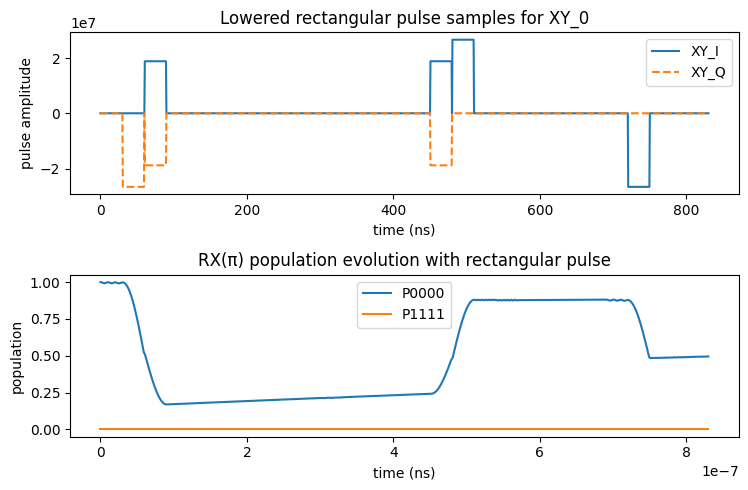

In [ ]:
solver_run = model.runs["run_0"]

pulse_ir = solver_run.artifacts.pulse_ir
pulse_ir_full = replace(pulse_ir, t_end_s=solver_run.results['param_0'].trajectories['shot_0'].times[-1])

pulse_samples = PulseCompiler.compile(pulse_ir_full, sample_rate_Hz=1e10)
xy_key = next(key for key in pulse_samples if key.startswith("XY_"))
t_pulse_ns = pulse_samples[xy_key]["t"] * 1e9
y_i = pulse_samples[xy_key]["y"]
y_q = pulse_samples[xy_key].get("y_quadrature", np.zeros_like(y_i))

fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot(2, 1, 1)
ax.plot(t_pulse_ns, y_i, label="XY_I")
ax.plot(t_pulse_ns, y_q, linestyle="--", label="XY_Q")
ax.set_xlabel("time (ns)")
ax.set_ylabel("pulse amplitude")
ax.set_title(f"Lowered rectangular pulse samples for {xy_key}")
ax.legend()


ax = fig.add_subplot(2, 1, 2)
pops = analysis.output.metrics['population']
for key, label in [('0000', "P0000"), ('1111', "P1111")]:
    ax.plot(pops.times, pops.values[key], label=label)
ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.set_title("RX(π) population evolution with rectangular pulse")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "pulse_and_population.png", dpi=600)
plt.show()
